# Breast Cancer Diagnostic Dataset - Exploratory Data Analysis

This notebook provides a comprehensive analysis of the breast cancer diagnostic dataset for Machine Learning Exercise 1.

## 1. Import Required Libraries

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Statistical libraries
from scipy import stats
from scipy.stats import skew, kurtosis

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Dataset

In [2]:
# Load the dataset
data_path = '../data/breast-cancer-diagnostic.shuf.lrn.csv'
df = pd.read_csv(data_path)

print(f"Dataset loaded successfully!")
print(f"Shape of the dataset: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

Dataset loaded successfully!
Shape of the dataset: (285, 32)
Number of samples: 285
Number of features: 32


## 3. Basic Dataset Information

In [3]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,ID,class,radiusMean,textureMean,perimeterMean,areaMean,smoothnessMean,compactnessMean,concavityMean,concavePointsMean,...,radiusWorst,textureWorst,perimeterWorst,areaWorst,smoothnessWorst,compactnessWorst,concavityWorst,concavePointsWorst,symmetryWorst,fractalDimensionWorst
0,8813129,False,13.27,17.02,84.55,546.4,0.08445,0.04994,0.03554,0.024560,...,15.14,23.60,98.84,708.8,0.1276,0.1311,0.17860,0.09678,0.2506,0.07623
1,898678,False,12.06,18.90,76.66,445.3,0.08386,0.05794,0.00751,0.008488,...,13.64,27.06,86.54,562.6,0.1289,0.1352,0.04506,0.05093,0.2880,0.08083
2,917896,False,13.71,18.68,88.73,571.0,0.09916,0.10700,0.05385,0.037830,...,15.11,25.63,99.43,701.9,0.1425,0.2566,0.19350,0.12840,0.2849,0.09031
3,869691,True,11.80,16.58,78.99,432.0,0.10910,0.17000,0.16590,0.074150,...,13.74,26.38,91.93,591.7,0.1385,0.4092,0.45040,0.18650,0.5774,0.10300
4,9110127,True,18.03,16.85,117.50,990.0,0.08947,0.12320,0.10900,0.062540,...,20.38,22.02,133.30,1292.0,0.1263,0.2666,0.42900,0.15350,0.2842,0.08225


In [4]:
# Display last few rows
print("Last 5 rows of the dataset:")
df.tail()

Last 5 rows of the dataset:


,ID,class,radiusMean,textureMean,perimeterMean,areaMean,smoothnessMean,compactnessMean,concavityMean,concavePointsMean,...,radiusWorst,textureWorst,perimeterWorst,areaWorst,smoothnessWorst,compactnessWorst,concavityWorst,concavePointsWorst,symmetryWorst,fractalDimensionWorst
280,89864002,False,11.71,15.45,75.03,420.3,0.11500,0.07281,0.04006,0.03250,...,13.06,18.16,84.16,516.4,0.1460,0.11150,0.1087,0.07864,0.2765,0.07806
281,884626,False,12.89,14.11,84.95,512.2,0.08760,0.13460,0.13740,0.03980,...,14.39,17.70,105.00,639.1,0.1254,0.58490,0.7727,0.15610,0.2639,0.11780
282,892189,True,11.76,18.14,75.00,431.1,0.09968,0.05914,0.02685,0.03515,...,13.36,23.39,85.10,553.6,0.1137,0.07974,0.0612,0.07160,0.1978,0.06915
283,919812,False,11.69,24.44,76.37,406.4,0.12360,0.15520,0.04515,0.04531,...,12.98,32.19,86.12,487.7,0.1768,0.32510,0.1395,0.13080,0.2803,0.09970
284,8810158,False,13.11,22.54,87.02,529.4,0.10020,0.14830,0.08705,0.05102,...,14.55,29.16,99.48,639.3,0.1349,0.44020,0.3162,0.11260,0.4128,0.10760


In [5]:
# Display column names and data types
print("Dataset Information:")
print("="*50)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       285 non-null    int64  
 1   class                    285 non-null    bool   
 2   radiusMean               285 non-null    float64
 3    textureMean             285 non-null    float64
 4    perimeterMean           285 non-null    float64
 5    areaMean                285 non-null    float64
 6    smoothnessMean          285 non-null    float64
 7    compactnessMean         285 non-null    float64
 8    concavityMean           285 non-null    float64
 9    concavePointsMean       285 non-null    float64
 10   symmetryMean            285 non-null    float64
 11   fractalDimensionMean    285 non-null    float64
 12   radiusStdErr            285 non-null    float64
 13   textureStdErr           285 non-null    float64
 14   peri

In [6]:
# Display column names
print("Column names:")
print(df.columns.tolist())

Column names:
['ID', 'class', 'radiusMean', ' textureMean', ' perimeterMean', ' areaMean', ' smoothnessMean', ' compactnessMean', ' concavityMean', ' concavePointsMean', ' symmetryMean', ' fractalDimensionMean', ' radiusStdErr', ' textureStdErr', ' perimeterStdErr', ' areaStdErr', ' smoothnessStdErr', ' compactnessStdErr', ' concavityStdErr', ' concavePointsStdErr', ' symmetryStdErr', ' fractalDimensionStdErr', ' radiusWorst', ' textureWorst', ' perimeterWorst', ' areaWorst', ' smoothnessWorst', ' compactnessWorst', ' concavityWorst', ' concavePointsWorst', ' symmetryWorst', ' fractalDimensionWorst']


## 4. Identify Target Variable and Features

In [7]:
# Identify potential target variable
# Usually the target variable is 'diagnosis', 'class', 'target', or similar
# Let's check for columns that might be the target

print("Checking for potential target variables...")
print("\nUnique value counts for each column:")
print("="*50)

for col in df.columns:
    unique_count = df[col].nunique()
    if unique_count <= 10:  # Likely categorical if few unique values
        print(f"{col}: {unique_count} unique values")
        print(f"  Values: {df[col].unique()[:10]}")
        print()

Checking for potential target variables...

Unique value counts for each column:
class: 2 unique values
  Values: [False  True]



In [8]:
# Based on the column names, identify the target variable
# Common names: 'diagnosis', 'class', 'target', 'label'
target_candidates = ['diagnosis', 'class', 'target', 'label']
target_column = None

for candidate in target_candidates:
    if candidate in df.columns:
        target_column = candidate
        break

# If no standard name found, check for binary columns
if target_column is None:
    for col in df.columns:
        if df[col].nunique() == 2:
            print(f"Potential binary target variable: {col}")
            print(f"Values: {df[col].unique()}")

if target_column:
    print(f"\nIdentified target variable: {target_column}")
    feature_columns = [col for col in df.columns if col != target_column]
    print(f"Number of feature columns: {len(feature_columns)}")
else:
    print("\nPlease manually identify the target variable from the columns above.")
    feature_columns = df.columns.tolist()


Identified target variable: class
Number of feature columns: 31


## 5. Statistical Summary

In [9]:
# Statistical summary of numerical features
print("Statistical Summary of Numerical Features:")
print("="*50)
df.describe()

Statistical Summary of Numerical Features:


,ID,radiusMean,textureMean,perimeterMean,areaMean,smoothnessMean,compactnessMean,concavityMean,concavePointsMean,symmetryMean,...,radiusWorst,textureWorst,perimeterWorst,areaWorst,smoothnessWorst,compactnessWorst,concavityWorst,concavePointsWorst,symmetryWorst,fractalDimensionWorst
count,2.850000e+02,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,...,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000
mean,2.861498e+07,14.068674,19.116211,91.555053,649.617895,0.095851,0.102605,0.085587,0.047930,0.182908,...,16.214354,25.568737,106.866175,878.226316,0.131940,0.251042,0.263251,0.113729,0.291636,0.083341
std,1.204247e+08,3.486377,4.516754,24.028687,343.979266,0.013894,0.051422,0.075717,0.037409,0.028606,...,4.820742,6.318778,33.390308,572.257246,0.022377,0.153795,0.199783,0.067461,0.062957,0.016335
min,8.670000e+03,6.981000,10.380000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.121500,...,7.930000,12.490000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.160300,0.058430
25%,8.711490e+05,11.690000,15.900000,74.680000,418.700000,0.086000,0.062190,0.026880,0.020690,0.162100,...,13.010000,20.720000,84.160000,515.300000,0.116600,0.141500,0.111700,0.064130,0.250600,0.071910
50%,9.065390e+05,13.280000,18.700000,86.100000,546.400000,0.095140,0.092280,0.061950,0.033260,0.181400,...,14.970000,25.410000,97.820000,684.500000,0.131200,0.215800,0.217700,0.099750,0.284100,0.079570
75%,8.811523e+06,16.070000,21.840000,105.800000,797.800000,0.105100,0.130400,0.122600,0.073400,0.197600,...,19.070000,30.280000,126.300000,1124.000000,0.144000,0.323500,0.382900,0.162800,0.319800,0.090750
max,9.113205e+08,27.420000,39.280000,186.900000,2501.000000,0.163400,0.345400,0.410800,0.168900,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.218400,0.937900,0.901900,0.290300,0.577400,0.143100


In [10]:
# Extended statistical summary
print("Extended Statistical Summary:")
print("="*50)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

stats_df = pd.DataFrame()
stats_df['mean'] = df[numerical_cols].mean()
stats_df['median'] = df[numerical_cols].median()
stats_df['std'] = df[numerical_cols].std()
stats_df['min'] = df[numerical_cols].min()
stats_df['max'] = df[numerical_cols].max()
stats_df['range'] = stats_df['max'] - stats_df['min']
stats_df['skewness'] = df[numerical_cols].skew()
stats_df['kurtosis'] = df[numerical_cols].kurtosis()
stats_df['cv'] = (stats_df['std'] / stats_df['mean']) * 100  # Coefficient of variation

stats_df.round(3)

Extended Statistical Summary:


,mean,median,std,min,max,range,skewness,kurtosis,cv
ID,2.861498e+07,906539.000,1.204247e+08,8670.000,9.113205e+08,9.113118e+08,6.801,47.050,420.845
radiusMean,1.406900e+01,13.280,3.486000e+00,6.981,2.742000e+01,2.043900e+01,0.812,0.459,24.781
textureMean,1.911600e+01,18.700,4.517000e+00,10.380,3.928000e+01,2.890000e+01,0.790,1.230,23.628
perimeterMean,9.155500e+01,86.100,2.402900e+01,43.790,1.869000e+02,1.431100e+02,0.857,0.591,26.245
areaMean,6.496180e+02,546.400,3.439790e+02,143.500,2.501000e+03,2.357500e+03,1.523,3.190,52.951
smoothnessMean,9.600000e-02,0.095,1.400000e-02,0.053,1.630000e-01,1.110000e-01,0.378,1.349,14.495
compactnessMean,1.030000e-01,0.092,5.100000e-02,0.019,3.450000e-01,3.260000e-01,1.087,1.662,50.116
concavityMean,8.600000e-02,0.062,7.600000e-02,0.000,4.110000e-01,4.110000e-01,1.323,1.973,88.468
concavePointsMean,4.800000e-02,0.033,3.700000e-02,0.000,1.690000e-01,1.690000e-01,0.995,0.420,78.050
symmetryMean,1.830000e-01,0.181,2.900000e-02,0.122,3.040000e-01,1.820000e-01,0.792,1.644,15.640


## 6. Missing Values Analysis

In [11]:
# Check for missing values
print("Missing Values Analysis:")
print("="*50)

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_count,
    'Percentage': missing_percentage
})

missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    print("Columns with missing values:")
    print(missing_df)
else:
    print("No missing values found in the dataset!")

# Visualize missing values if any exist
if len(missing_df) > 0:
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(missing_df)), missing_df['Percentage'])
    plt.xticks(range(len(missing_df)), missing_df.index, rotation=45)
    plt.xlabel('Features')
    plt.ylabel('Percentage of Missing Values')
    plt.title('Missing Values by Feature')
    plt.tight_layout()
    plt.show()

Missing Values Analysis:
No missing values found in the dataset!


## 7. Target Variable Distribution

Target Variable: class
Class Distribution:
       Count  Percentage
class                   
False    177   62.105263
True     108   37.894737

Imbalance Ratio: 1.64


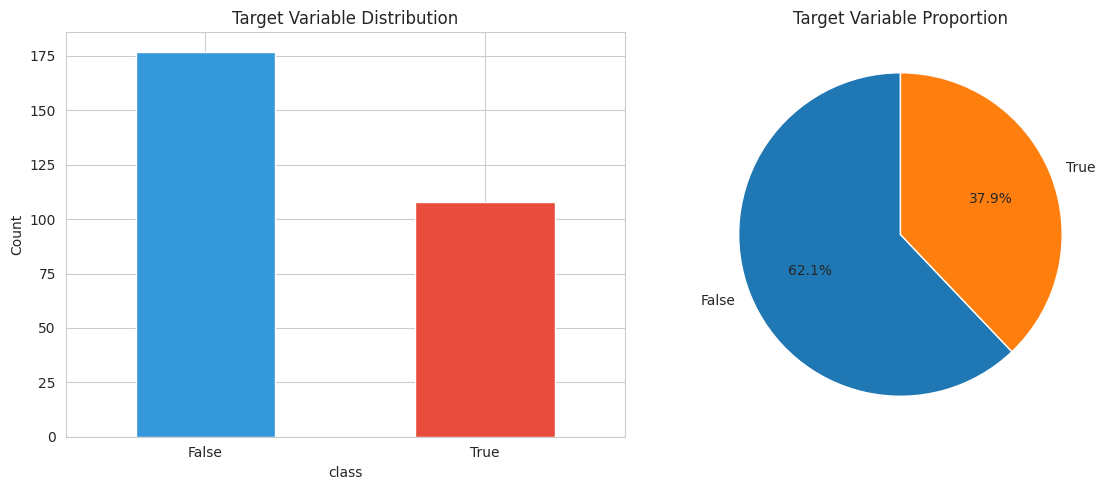

In [12]:
# If target variable is identified, analyze its distribution
if target_column and target_column in df.columns:
    print(f"Target Variable: {target_column}")
    print("="*50)
    
    # Value counts
    target_counts = df[target_column].value_counts()
    target_percentages = df[target_column].value_counts(normalize=True) * 100
    
    target_dist = pd.DataFrame({
        'Count': target_counts,
        'Percentage': target_percentages
    })
    
    print("Class Distribution:")
    print(target_dist)
    
    # Check for class imbalance
    imbalance_ratio = target_counts.max() / target_counts.min()
    print(f"\nImbalance Ratio: {imbalance_ratio:.2f}")
    if imbalance_ratio > 2:
        print("⚠️ Warning: Dataset appears to be imbalanced!")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Bar plot
    target_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
    axes[0].set_title('Target Variable Distribution')
    axes[0].set_xlabel(target_column)
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
    
    # Pie chart
    target_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Target Variable Proportion')
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()
else:
    print("Target variable not identified. Please specify it manually.")

## 8. Feature Distributions

Number of numerical features: 31


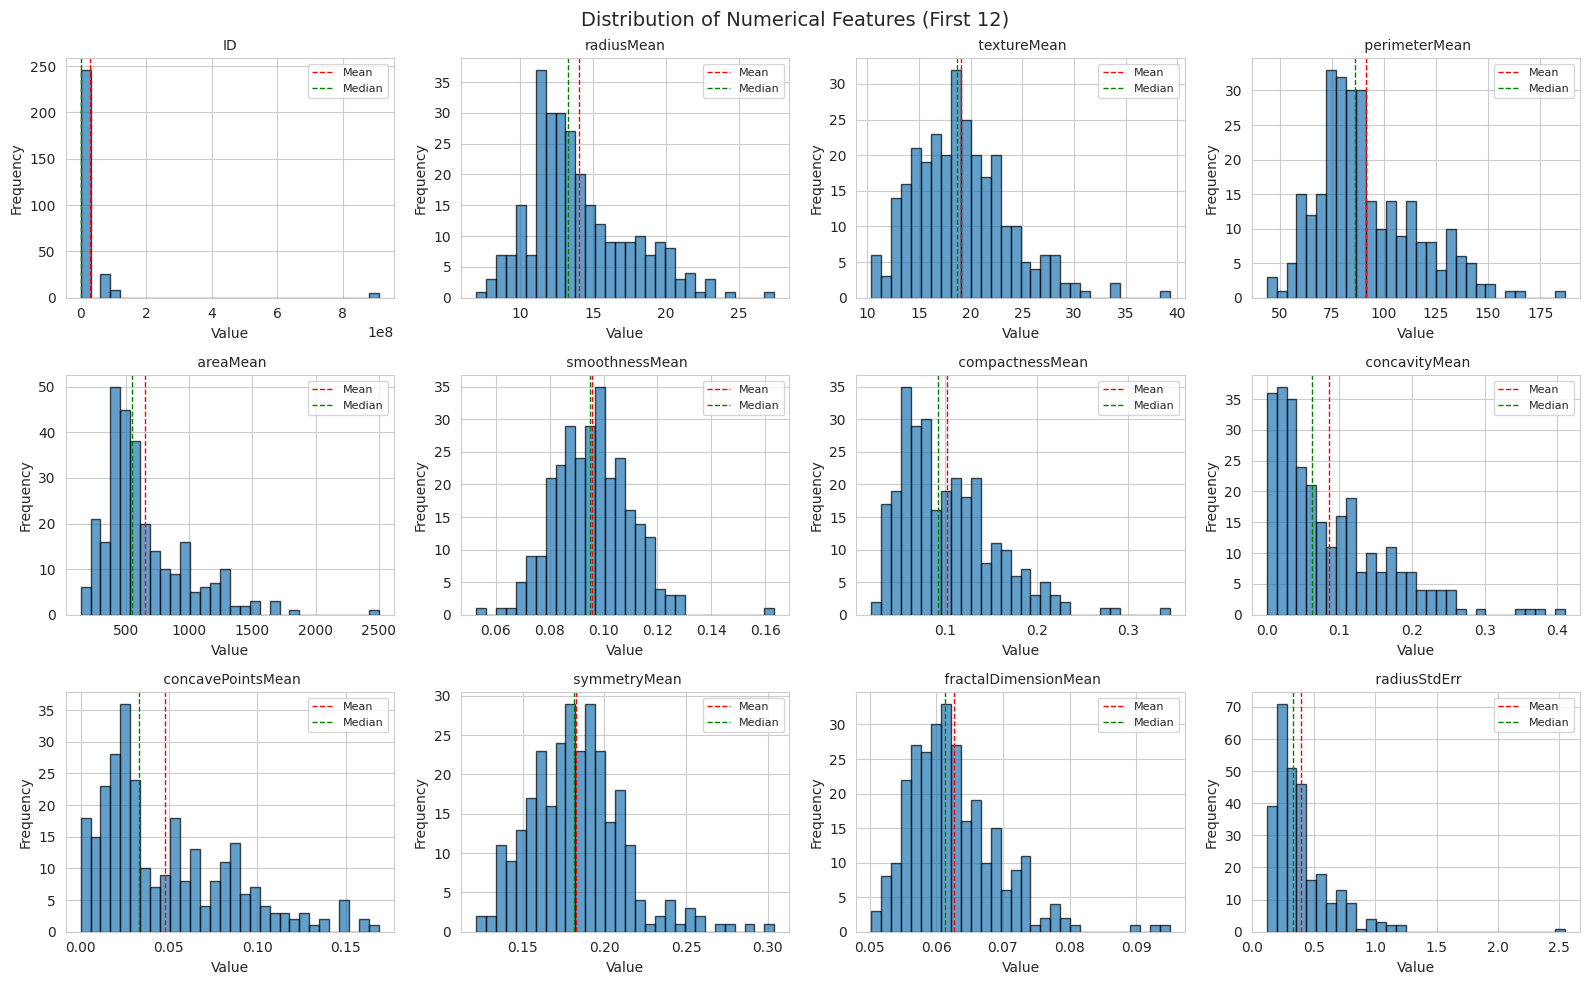

In [13]:
# Plot distribution of numerical features
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target variable if it's numerical
if target_column and target_column in numerical_features:
    numerical_features.remove(target_column)

print(f"Number of numerical features: {len(numerical_features)}")

# Plot first 12 features
n_features_to_plot = min(12, len(numerical_features))
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_features[:n_features_to_plot]):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}', fontsize=10)
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    
    # Add mean and median lines
    axes[idx].axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
    axes[idx].axvline(df[col].median(), color='green', linestyle='dashed', linewidth=1, label='Median')
    axes[idx].legend(fontsize=8)

plt.suptitle('Distribution of Numerical Features (First 12)', fontsize=14)
plt.tight_layout()
plt.show()

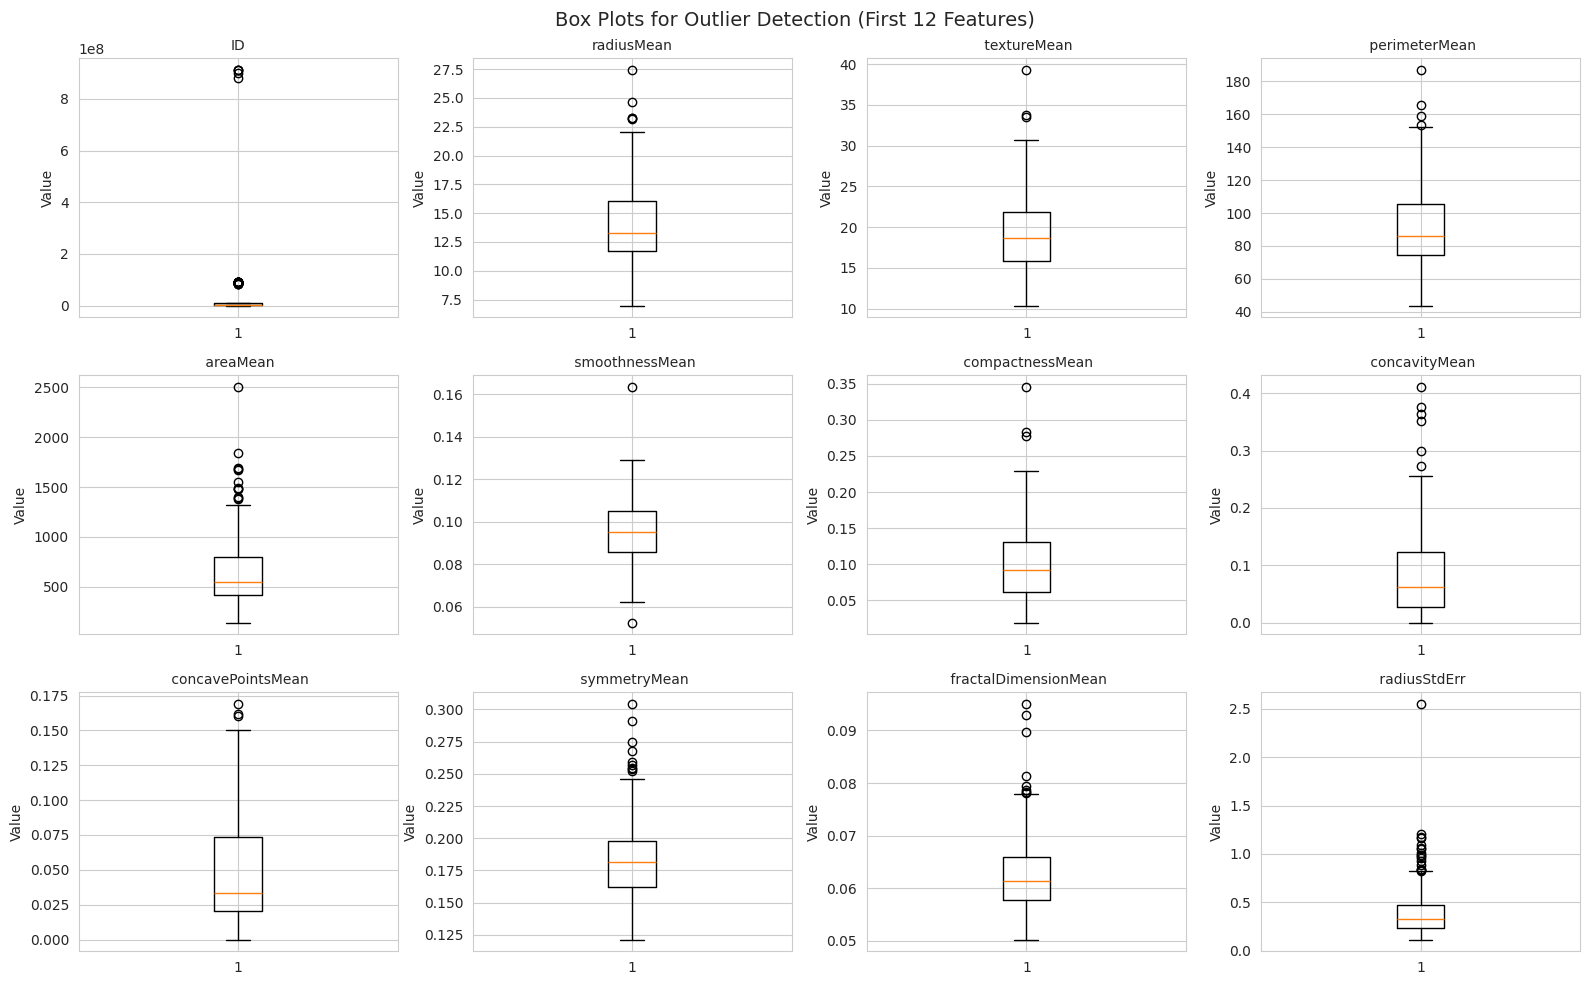

In [14]:
# Box plots for numerical features to identify outliers
if len(numerical_features) > 0:
    n_features_to_plot = min(12, len(numerical_features))
    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    axes = axes.ravel()
    
    for idx, col in enumerate(numerical_features[:n_features_to_plot]):
        axes[idx].boxplot(df[col].dropna())
        axes[idx].set_title(f'{col}', fontsize=10)
        axes[idx].set_ylabel('Value')
    
    plt.suptitle('Box Plots for Outlier Detection (First 12 Features)', fontsize=14)
    plt.tight_layout()
    plt.show()

## 9. Feature Scaling Analysis

In [15]:
# Check if features need scaling
print("Feature Scaling Analysis:")
print("="*50)

if len(numerical_features) > 0:
    scaling_df = pd.DataFrame()
    scaling_df['Feature'] = numerical_features
    scaling_df['Min'] = df[numerical_features].min().values
    scaling_df['Max'] = df[numerical_features].max().values
    scaling_df['Range'] = scaling_df['Max'] - scaling_df['Min']
    scaling_df['Mean'] = df[numerical_features].mean().values
    scaling_df['Std'] = df[numerical_features].std().values
    
    # Sort by range to identify features with very different scales
    scaling_df = scaling_df.sort_values('Range', ascending=False)
    
    print("Top 10 features by range:")
    print(scaling_df.head(10))
    
    # Check if scaling is needed
    max_range_ratio = scaling_df['Range'].max() / scaling_df['Range'].min()
    print(f"\nMaximum range ratio: {max_range_ratio:.2f}")
    
    if max_range_ratio > 100:
        print("⚠️ Strong recommendation: Feature scaling is needed!")
        print("   Features have very different scales.")
    elif max_range_ratio > 10:
        print("⚠️ Recommendation: Consider feature scaling.")
        print("   Features have moderately different scales.")
    else:
        print("✓ Features are on similar scales.")

Feature Scaling Analysis:
Top 10 features by range:
            Feature       Min           Max         Range          Mean  \
0                ID  8670.000  9.113205e+08  9.113118e+08  2.861498e+07   
24        areaWorst   185.200  4.254000e+03  4.068800e+03  8.782263e+02   
4          areaMean   143.500  2.501000e+03  2.357500e+03  6.496179e+02   
14       areaStdErr     7.254  5.422000e+02  5.349460e+02  3.943303e+01   
23   perimeterWorst    50.410  2.512000e+02  2.007900e+02  1.068662e+02   
3     perimeterMean    43.790  1.869000e+02  1.431100e+02  9.155505e+01   
22     textureWorst    12.490  4.954000e+01  3.705000e+01  2.556874e+01   
2       textureMean    10.380  3.928000e+01  2.890000e+01  1.911621e+01   
21      radiusWorst     7.930  3.604000e+01  2.811000e+01  1.621435e+01   
1        radiusMean     6.981  2.742000e+01  2.043900e+01  1.406867e+01   

             Std  
0   1.204247e+08  
24  5.722572e+02  
4   3.439793e+02  
14  4.402047e+01  
23  3.339031e+01  
3   2.40

## 10. Correlation Analysis

Correlation Analysis:


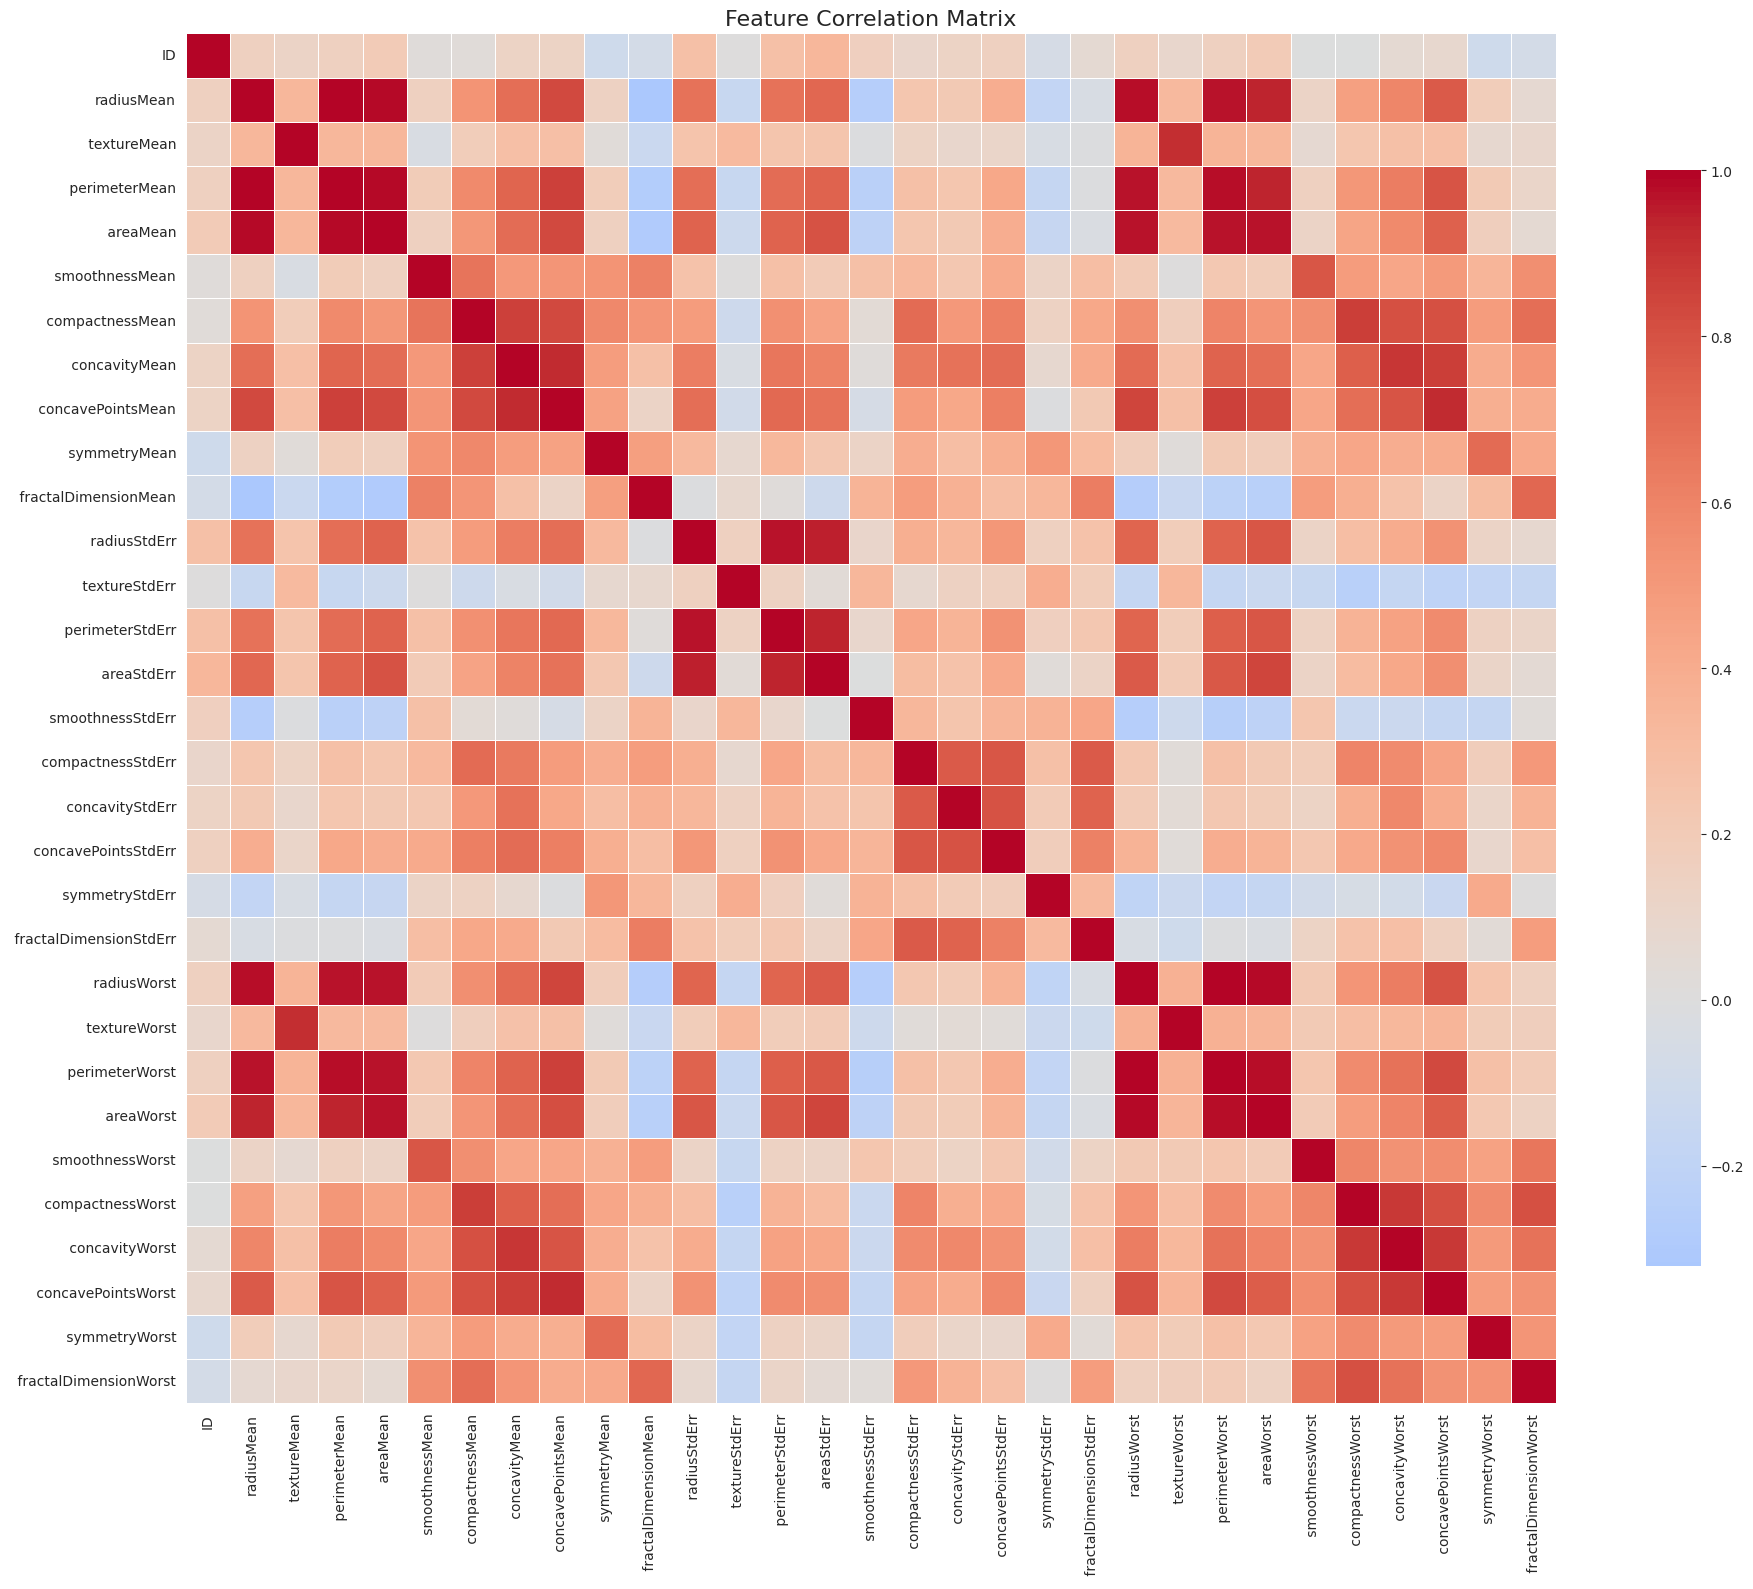

In [16]:
# Correlation matrix for numerical features
if len(numerical_features) > 0:
    print("Correlation Analysis:")
    print("="*50)
    
    corr_matrix = df[numerical_features].corr()
    
    # Plot correlation heatmap
    plt.figure(figsize=(20, 16))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Matrix', fontsize=16)
    plt.tight_layout()
    plt.show()

In [17]:
# Find highly correlated feature pairs
if len(numerical_features) > 1:
    print("Highly Correlated Feature Pairs (|correlation| > 0.8):")
    print("="*50)
    
    # Get upper triangle of correlation matrix
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    # Find highly correlated pairs
    high_corr_pairs = []
    for column in upper_tri.columns:
        for index in upper_tri.index:
            if abs(upper_tri.loc[index, column]) > 0.8:
                high_corr_pairs.append((
                    index, column, upper_tri.loc[index, column]
                ))
    
    # Sort by absolute correlation
    high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    
    if high_corr_pairs:
        high_corr_df = pd.DataFrame(
            high_corr_pairs, 
            columns=['Feature 1', 'Feature 2', 'Correlation']
        )
        print(high_corr_df)
        print(f"\n⚠️ Found {len(high_corr_pairs)} highly correlated feature pairs.")
        print("   Consider removing one feature from each pair to avoid multicollinearity.")
    else:
        print("✓ No highly correlated feature pairs found.")

Highly Correlated Feature Pairs (|correlation| > 0.8):
             Feature 1               Feature 2  Correlation
0           radiusMean           perimeterMean     0.997917
1          radiusWorst          perimeterWorst     0.994108
2           radiusMean                areaMean     0.986544
3        perimeterMean                areaMean     0.985754
4          radiusWorst               areaWorst     0.982171
5       perimeterWorst               areaWorst     0.976889
6        perimeterMean          perimeterWorst     0.974502
7           radiusMean             radiusWorst     0.974413
8        perimeterMean             radiusWorst     0.974166
9         radiusStdErr         perimeterStdErr     0.972245
10            areaMean             radiusWorst     0.971577
11          radiusMean          perimeterWorst     0.969640
12            areaMean               areaWorst     0.968140
13            areaMean          perimeterWorst     0.967910
14        radiusStdErr              areaStdEr

## 11. Outlier Detection

Outlier Detection (IQR Method):
Top 10 features with most outliers:
                   Feature  Outlier_Count  Percentage
0                       ID             39   13.684211
14              areaStdErr             31   10.877193
15        smoothnessStdErr             18    6.315789
11            radiusStdErr             17    5.964912
13         perimeterStdErr             16    5.614035
17         concavityStdErr             13    4.561404
19          symmetryStdErr             13    4.561404
30   fractalDimensionWorst             13    4.561404
24               areaWorst             12    4.210526
4                 areaMean             12    4.210526


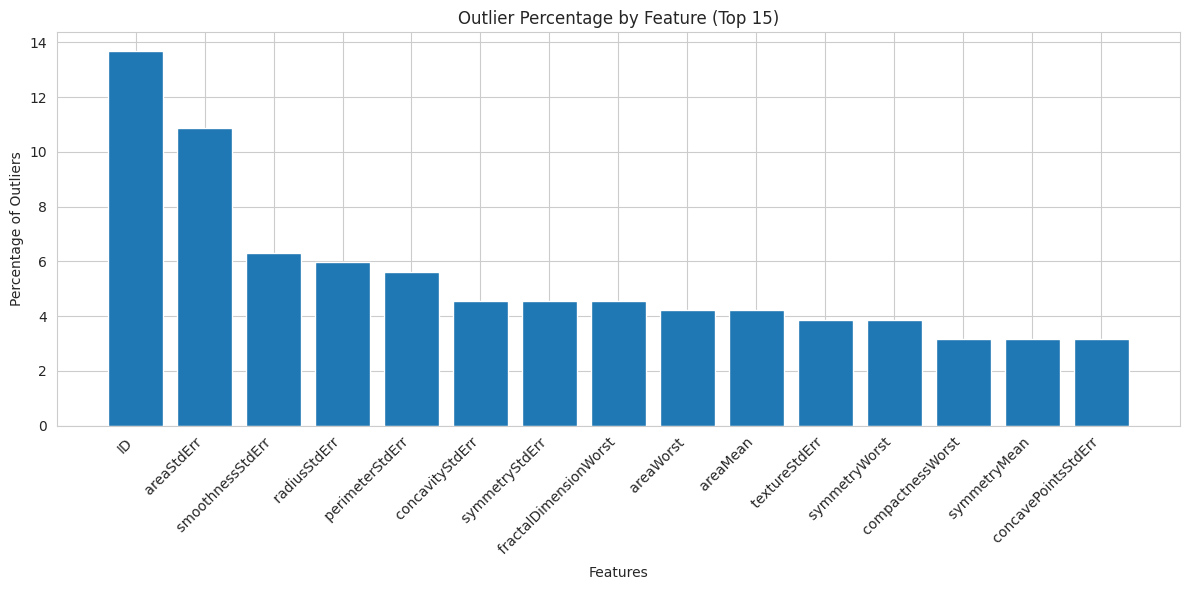

In [18]:
# Detect outliers using IQR method
print("Outlier Detection (IQR Method):")
print("="*50)

outlier_counts = {}
outlier_percentages = {}

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)
    outlier_percentages[col] = (len(outliers) / len(df)) * 100

# Create outlier summary DataFrame
outlier_df = pd.DataFrame({
    'Feature': list(outlier_counts.keys()),
    'Outlier_Count': list(outlier_counts.values()),
    'Percentage': list(outlier_percentages.values())
})

outlier_df = outlier_df.sort_values('Outlier_Count', ascending=False)

print("Top 10 features with most outliers:")
print(outlier_df.head(10))

# Visualize outlier counts
if len(outlier_df) > 0:
    plt.figure(figsize=(12, 6))
    top_outlier_features = outlier_df.head(15)
    plt.bar(range(len(top_outlier_features)), top_outlier_features['Percentage'])
    plt.xticks(range(len(top_outlier_features)), top_outlier_features['Feature'], rotation=45, ha='right')
    plt.xlabel('Features')
    plt.ylabel('Percentage of Outliers')
    plt.title('Outlier Percentage by Feature (Top 15)')
    plt.tight_layout()
    plt.show()

## 12. Feature Importance (if target variable is identified)

Feature Importance Analysis (using Random Forest):
Top 15 most important features:
                Feature  Importance
24            areaWorst    0.127138
23       perimeterWorst    0.120997
28   concavePointsWorst    0.117824
21          radiusWorst    0.108615
8     concavePointsMean    0.057692
7         concavityMean    0.056958
14           areaStdErr    0.056656
27       concavityWorst    0.054493
3         perimeterMean    0.048402
4              areaMean    0.040450
1            radiusMean    0.026370
26     compactnessWorst    0.025413
22         textureWorst    0.020780
2           textureMean    0.016468
13      perimeterStdErr    0.016023


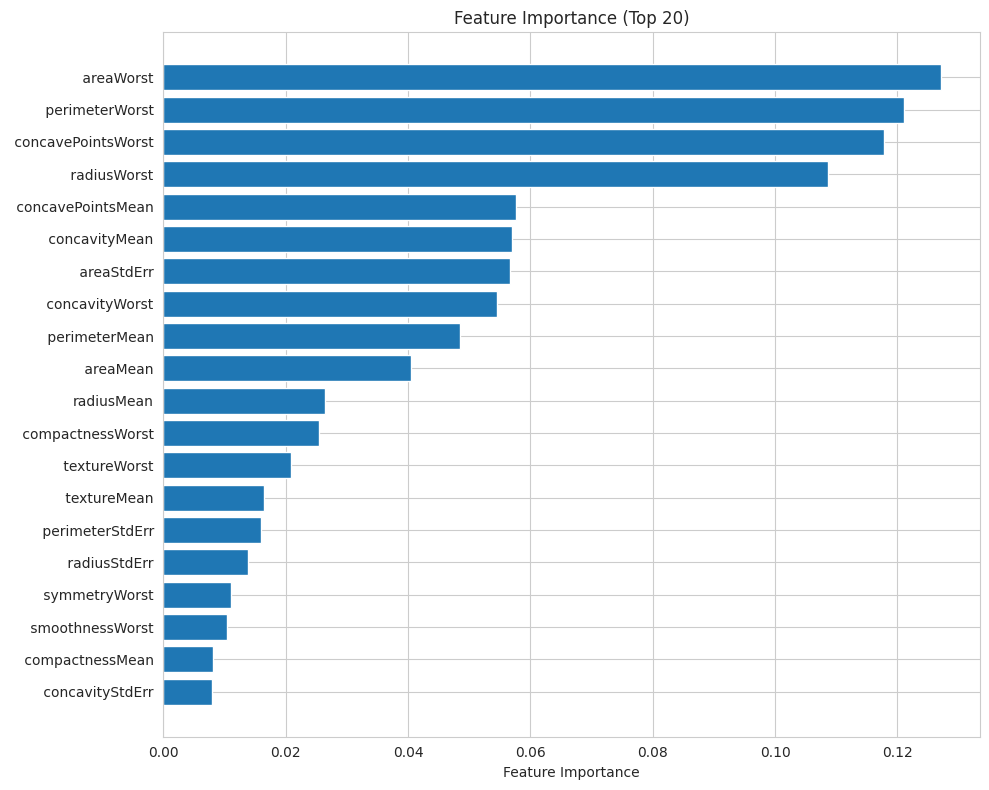

In [19]:
# If target variable is identified and is categorical, analyze feature importance
if target_column and target_column in df.columns:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.preprocessing import LabelEncoder
    
    print("Feature Importance Analysis (using Random Forest):")
    print("="*50)
    
    # Prepare data
    X = df[numerical_features].fillna(df[numerical_features].mean())
    
    # Encode target if it's categorical
    le = LabelEncoder()
    y = le.fit_transform(df[target_column])
    
    # Train a simple Random Forest to get feature importance
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    
    # Get feature importance
    importance_df = pd.DataFrame({
        'Feature': numerical_features,
        'Importance': rf.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("Top 15 most important features:")
    print(importance_df.head(15))
    
    # Visualize feature importance
    plt.figure(figsize=(10, 8))
    top_features = importance_df.head(20)
    plt.barh(range(len(top_features)), top_features['Importance'])
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Feature Importance')
    plt.title('Feature Importance (Top 20)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 13. Data Quality Summary

In [20]:
# Summary of data quality issues and recommendations
print("DATA QUALITY SUMMARY AND RECOMMENDATIONS")
print("="*60)

# Dataset characteristics
print("\n📊 Dataset Characteristics:")
print(f"   - Number of samples: {df.shape[0]}")
print(f"   - Number of features: {df.shape[1] - 1 if target_column else df.shape[1]}")
print(f"   - Number of numerical features: {len(numerical_features)}")
print(f"   - Number of categorical features: {df.shape[1] - len(numerical_features) - (1 if target_column else 0)}")

# Missing values
total_missing = df.isnull().sum().sum()
print(f"\n🔍 Missing Values:")
if total_missing == 0:
    print("   ✓ No missing values found")
else:
    print(f"   ⚠️ Total missing values: {total_missing}")
    print(f"   ⚠️ Columns with missing values: {len(missing_df)}")
    print("   → Recommendation: Impute missing values using mean/median or drop if percentage is low")

# Class imbalance
if target_column and target_column in df.columns:
    print(f"\n⚖️ Class Balance:")
    if imbalance_ratio > 2:
        print(f"   ⚠️ Dataset is imbalanced (ratio: {imbalance_ratio:.2f})")
        print("   → Recommendation: Consider SMOTE, class weights, or stratified sampling")
    else:
        print("   ✓ Classes are relatively balanced")

# Feature scaling
print(f"\n📏 Feature Scaling:")
if len(numerical_features) > 0 and max_range_ratio > 10:
    print(f"   ⚠️ Features have different scales (max ratio: {max_range_ratio:.2f})")
    print("   → Recommendation: Apply StandardScaler or MinMaxScaler")
else:
    print("   ✓ Features are on similar scales")

# Highly correlated features
if 'high_corr_pairs' in locals() and high_corr_pairs:
    print(f"\n🔗 Feature Correlation:")
    print(f"   ⚠️ Found {len(high_corr_pairs)} highly correlated feature pairs")
    print("   → Recommendation: Consider removing redundant features or using PCA")
else:
    print(f"\n🔗 Feature Correlation:")
    print("   ✓ No highly correlated features found")

# Outliers
high_outlier_features = outlier_df[outlier_df['Percentage'] > 5]
print(f"\n📌 Outliers:")
if len(high_outlier_features) > 0:
    print(f"   ⚠️ {len(high_outlier_features)} features have >5% outliers")
    print("   → Recommendation: Consider outlier removal or robust scaling")
else:
    print("   ✓ Outlier levels are acceptable")

print("\n" + "="*60)
print("\n🎯 PREPROCESSING PIPELINE RECOMMENDATIONS:")
print("   1. Handle missing values (if any)")
print("   2. Encode categorical variables (if any)")
print("   3. Apply feature scaling (StandardScaler recommended)")
print("   4. Consider feature selection or PCA for dimensionality reduction")
print("   5. Handle class imbalance (if present)")
print("   6. Split data using stratified sampling")
print("\n" + "="*60)

DATA QUALITY SUMMARY AND RECOMMENDATIONS

📊 Dataset Characteristics:
   - Number of samples: 285
   - Number of features: 31
   - Number of numerical features: 31
   - Number of categorical features: 0

🔍 Missing Values:
   ✓ No missing values found

⚖️ Class Balance:
   ✓ Classes are relatively balanced

📏 Feature Scaling:
   ⚠️ Features have different scales (max ratio: 31564190227.80)
   → Recommendation: Apply StandardScaler or MinMaxScaler

🔗 Feature Correlation:
   ⚠️ Found 41 highly correlated feature pairs
   → Recommendation: Consider removing redundant features or using PCA

📌 Outliers:
   ⚠️ 5 features have >5% outliers
   → Recommendation: Consider outlier removal or robust scaling


🎯 PREPROCESSING PIPELINE RECOMMENDATIONS:
   1. Handle missing values (if any)
   2. Encode categorical variables (if any)
   3. Apply feature scaling (StandardScaler recommended)
   4. Consider feature selection or PCA for dimensionality reduction
   5. Handle class imbalance (if present)
   6

## 14. Save Analysis Results

In [21]:
# Save key statistics to CSV for later reference
analysis_results = {
    'Dataset_Shape': f"{df.shape[0]} x {df.shape[1]}",
    'Missing_Values': total_missing,
    'Numerical_Features': len(numerical_features),
    'Target_Column': target_column if target_column else 'Not identified',
    'Class_Imbalance_Ratio': imbalance_ratio if 'imbalance_ratio' in locals() else 'N/A',
    'Max_Range_Ratio': max_range_ratio if 'max_range_ratio' in locals() else 'N/A',
    'Highly_Correlated_Pairs': len(high_corr_pairs) if 'high_corr_pairs' in locals() else 0
}

# Save to file
analysis_df = pd.DataFrame([analysis_results])
analysis_df.to_csv('eda_summary.csv', index=False)
print("Analysis summary saved to 'eda_summary.csv'")

# Save feature statistics
if 'stats_df' in locals():
    stats_df.to_csv('feature_statistics.csv')
    print("Feature statistics saved to 'feature_statistics.csv'")

print("\n✅ Exploratory Data Analysis Complete!")

Analysis summary saved to 'eda_summary.csv'
Feature statistics saved to 'feature_statistics.csv'

✅ Exploratory Data Analysis Complete!


# Breast Cancer Diagnostic Dataset — EDA Summary

## Dataset

* **File:** `breast-cancer-diagnostic.shuf.lrn.csv`
* **Samples:** 285
* **Columns:** 32 (31 features + 1 target)
* **Missing values:** none (all 285 non-null)
* **Dtypes:** 30 × `float64`, 1 × `int64`, 1 × `bool`

> Note: Several column names contain **leading spaces** (e.g., `' textureMean'`). Normalize/trim column names before modeling.

## Target and Features

* **Target:** `class` (`bool`; values: `False`, `True`)
* **Identifier:** `ID` (non-informative for prediction) → **drop for modeling**.
* **Feature families:**

  * Central tendency: `radiusMean`, `textureMean`, `perimeterMean`, `areaMean`, `smoothnessMean`, `compactnessMean`, `concavityMean`, `concavePointsMean`, `symmetryMean`, `fractalDimensionMean`.
  * Variability (stderr): `radiusStdErr`, `textureStdErr`, …, `fractalDimensionStdErr`.
  * "Worst" measures: `radiusWorst`, `textureWorst`, …, `fractalDimensionWorst`.

## Descriptive Statistics (high-level)

* **Location & scale (examples):**

  * `radiusMean` **mean** ≈ **14.07**, **std** ≈ **3.49**
  * `areaMean` **mean** ≈ **649.6**, **std** ≈ **344.0**
  * `radiusWorst` **mean** ≈ **16.21**, **std** ≈ **4.82**
  * `areaWorst` **mean** ≈ **878.2**, **std** ≈ **572.3**
* **Right-skewness** is common across size/shape features (e.g., `perimeterMean`, `areaMean`, many "Worst" and "StdErr" features).
* **Heavy tails (high kurtosis)** in several stderr and worst metrics (e.g., `areaStdErr`, `concavityStdErr`, `fractalDimensionStdErr`) → **outlier sensitivity**.
* **Zeros present** in some features (e.g., `concavityMean`, `concavePointsMean`, and some `…StdErr/Worst`) → mass at 0, accentuating skew.
* **Large ranges** for area/perimeter families (e.g., `areaWorst` up to **4254**).

## Implications for Preprocessing

* **Column cleanup:** trim/standardize names; ensure consistent snake/camel case.
* **Drop `ID`.** It is an identifier, not predictive; also extremely skewed.
* **Scale features:** required due to heterogeneous scales and outliers.

  * Prefer **RobustScaler** (median/IQR) or StandardScaler after transforms.
* **Transform skewed variables:** log1p or similar for `area*`, `perimeter*`, `concavity*`, `concavePoints*`, `radius*` where appropriate.
* **Outlier handling:** consider winsorization or robust models; validate via sensitivity analysis.
* **Class balance:** verify distribution of `class`; if imbalanced, use stratification, threshold tuning, and report **ROC-AUC + PR-AUC**.

## Diagnostic Visuals (recommended)

* **Distributions:** histograms/density plots; compare raw vs. log-scale.
* **Correlation heatmap:** expect strong blocks among size triplets (radius–perimeter–area). Use to inform **regularization** or **feature selection**.
* **Class separation plots:** box/violin plots of key predictors by `class`.

## Modeling Roadmap (concise)

1. **Split & CV:** Stratified train/validation split; 5–10-fold cross-validation.
2. **Baselines:**

   * **Logistic Regression** (L1/L2) with scaled inputs.
   * **SVM (RBF)** with `C`, `γ` tuning.
   * **Tree ensembles:** Random Forest / Gradient Boosting (less sensitive to monotone transforms; still scale/transform to help comparability and training stability).
   * **kNN** as a non-parametric reference (benefits from scaling).
3. **Hyperparameters (examples):**

   * Logistic: `C ∈ {0.01, 0.1, 1, 10}`, penalty ∈ {L1, L2}
   * SVM: `C ∈ {0.1, 1, 10}`, `γ ∈ {1e-3, 1e-2, 1e-1}` (with feature scaling)
   * RF: `n_estimators ∈ {200, 500}`, `max_depth ∈ {None, 6, 10}`, `min_samples_leaf ∈ {1, 3, 5}`
   * GB/XGB-like: learning rate `∈ {0.01, 0.1}`, `n_estimators ∈ {200, 500}`, `max_depth ∈ {2, 4, 6}`
4. **Evaluation:** Accuracy, **F1**, **ROC-AUC**, **PR-AUC**; include calibration plot if thresholding.
5. **Explainability:** feature importances (tree-based), coefficients (log-reg), **permutation importance**, and partial dependence/ICE on top predictors.

## Quick Quality Checklist

* [ ] Column names trimmed and unique
* [ ] `ID` dropped
* [ ] Train/test split stratified by `class`
* [ ] Scaling/transform pipeline wrapped in `sklearn` `Pipeline`
* [ ] Cross-validated model selection with consistent metric
* [ ] Report includes sensitivity to transforms/outliers

---

*This summary condenses the exploratory analysis you performed into a clear, English markdown report aligned with downstream modeling needs.*

---

## Additional EDA Results (from latest code)

### Target distribution

* `False`: **177** (62.1%)
* `True`: **108** (37.9%)
* **Imbalance ratio:** 1.64 → *mild imbalance*. Use **stratified** splits and report **ROC-AUC + PR-AUC** but no heavy resampling needed.

### Scaling & ranges

* **Max range ratio:** **3.16×10¹⁰** (driven by `ID` vs. small-magnitude features). → **Scaling is mandatory.**
* Use **RobustScaler** (or StandardScaler after transforms). Consider **log1p** for strictly-positive, heavy‑tailed blocks: `area*`, `perimeter*`, `radius*`, `concavity*`, `concavePoints*`.

### Correlations (|r| > 0.8)

* **41** highly correlated pairs, dominated by the size triplet and their variants:

  * `radiusMean`–`perimeterMean` (0.998), `radiusMean`–`areaMean` (0.987), `perimeterMean`–`areaMean` (0.986)
  * Same pattern for *Worst* and *StdErr* families (e.g., `radiusWorst`–`areaWorst` 0.982).
  * Shape complexity block: `concavity*` ↔ `concavePoints*` (0.92+), `compactness*` ↔ `concavity*` (~0.86–0.89).
* **Implication:** High multicollinearity. Prefer **regularized linear models**, tree ensembles, or apply **feature grouping/drop** or **PCA**.

### Outliers (IQR method)

* Top features by outlier rate: `ID` (13.7%), `areaStdErr` (10.9%), `smoothnessStdErr` (6.3%), `radiusStdErr` (6.0%), `perimeterStdErr` (5.6%).
* **Action:** Drop `ID`. For others, consider **winsorization** or rely on **robust scaling / tree models**; validate with sensitivity analysis.

### Random‑Forest feature importance (top signals)

1. `areaWorst` (0.127)
2. `perimeterWorst` (0.121)
3. `concavePointsWorst` (0.118)
4. `radiusWorst` (0.109)
5. `concavePointsMean` (0.058)
6. `concavityMean` (0.057)
7. `areaStdErr` (0.057)
8. `concavityWorst` (0.054)

> Interpretation: **Worst** variants carry the strongest signal; mean measures of **concavity/concave points** also matter; area-related stderr contributes.

## Actionable preprocessing & modeling plan (concise)

### 1) Column cleanup & target

* Trim column names; drop duplicates if any arise after trimming.
* Drop **`ID`**.
* Keep `class` as target; encode to {0,1}.

### 2) Train/test split

* **Stratified** split (e.g., 80/20, random_state fixed). Report seed.

### 3) Pipeline (sklearn `Pipeline`/`ColumnTransformer`)

* **Log transforms (log1p):** `area*`, `perimeter*`, `radius*`, `concavity*`, `concavePoints*`.
* **Scaling:** `RobustScaler` for all numeric features.
* Optional: **Outlier cap** at 1st/99th percentiles for features with >5% outliers (e.g., `areaStdErr`).

### 4) Collinearity handling

* Simple rule: within each size block {radius, perimeter, area} keep **one mean + one worst**; or
* Use **PCA** (retain ~95% variance) as a separate pipeline branch for linear models; compare.

### 5) Models to benchmark

* **Logistic Regression** (L1 & L2)
* **SVM (RBF)**
* **Random Forest / Gradient Boosting**
* **kNN** baseline

### 6) Evaluation

* 5–10‑fold **Stratified CV** on the training set.
* Primary metrics: **ROC‑AUC**, **F1**, **balanced accuracy**; include **PR‑AUC** due to mild imbalance.
* Calibrate probabilities (Platt/Isotonic) for thresholding and PR‑curve analysis.

### 7) Reporting & artifacts

* Save: `eda_summary.csv`, `feature_statistics.csv`, CV tables, best params, and a **model card** (data, preprocessing, metrics, caveats).

---

### Quick checklist

* [ ] Column names trimmed
* [ ] `ID` dropped
* [ ] Stratified split
* [ ] Log1p on heavy‑tailed features
* [ ] Robust scaling
* [ ] Multicollinearity addressed (drop/group or PCA)
* [ ] CV and metrics logged
* [ ] Reproducible seeds & versions recorded


In [22]:
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, average_precision_score,
    confusion_matrix, classification_report, PrecisionRecallDisplay, RocCurveDisplay
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import joblib

In [24]:
df = deepcopy(df)
df.columns = [c.strip() for c in df.columns]  # trim spaces

TARGET = "class"
assert TARGET in df.columns, "Target column 'class' missing."

drop_cols = [c for c in ["ID"] if c in df.columns]
X = df.drop(columns=[TARGET] + drop_cols)
y = df[TARGET].astype(int)  # {False, True} -> {0,1}

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"Features: {len(num_features)} | Dropped: {drop_cols}")


Features: 30 | Dropped: ['ID']


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)
print("Train/Test sizes:", X_train.shape, X_test.shape)


Train/Test sizes: (228, 30) (57, 30)


In [26]:
from sklearn.preprocessing import FunctionTransformer

heavy_mask = X_train.columns.str.contains(
    r"(radius|perimeter|area|concavity|concavePoints)", case=False, regex=True
)
log_features = X_train.columns[heavy_mask].tolist()
linear_features = [c for c in num_features if c not in log_features]

preprocess = ColumnTransformer(
    transformers=[
        ("log_then_scale", Pipeline([
            ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("scale", RobustScaler())
        ]), log_features),
        ("scale_only", RobustScaler(), linear_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# quick sanity-transform to ensure no errors
_ = preprocess.fit_transform(X_train)
print(f"Log+scale on {len(log_features)} features; scale-only on {len(linear_features)} features.")


Log+scale on 15 features; scale-only on 15 features.


In [27]:
rf = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",  # mild imbalance in your target
    random_state=RANDOM_STATE,
    n_jobs=-1
)

pipe = Pipeline([
    ("prep", preprocess),
    ("rf", rf)
])


In [28]:
param_grid = {
    "rf__n_estimators": [300, 600],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_leaf": [1, 3, 5],
    "rf__max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")

best_model = grid.best_estimator_


/home/admdekapfer/.local/share/uv/python/cpython-3.13.9-linux-aarch64-gnu/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/admdekapfer/.local/share/uv/python/cpython-3.13.9-linux-aarch64-gnu/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/admdekapfer/.local/share/uv/python/cpython-3.13.9-linux-aarch64-gnu/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/e

Best params: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__n_estimators': 600}
Best CV ROC-AUC: 0.9929


In [29]:
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "PR-AUC": average_precision_score(y_test, y_prob),
}
print("\nTest metrics:")
for k, v in metrics.items():
    print(f"{k:>9}: {v:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))



Test metrics:
 Accuracy: 0.9298
Precision: 0.9091
   Recall: 0.9091
       F1: 0.9091
  ROC-AUC: 0.9662
   PR-AUC: 0.9670

Classification report:
              precision    recall  f1-score   support

           0      0.943     0.943     0.943        35
           1      0.909     0.909     0.909        22

    accuracy                          0.930        57
   macro avg      0.926     0.926     0.926        57
weighted avg      0.930     0.930     0.930        57



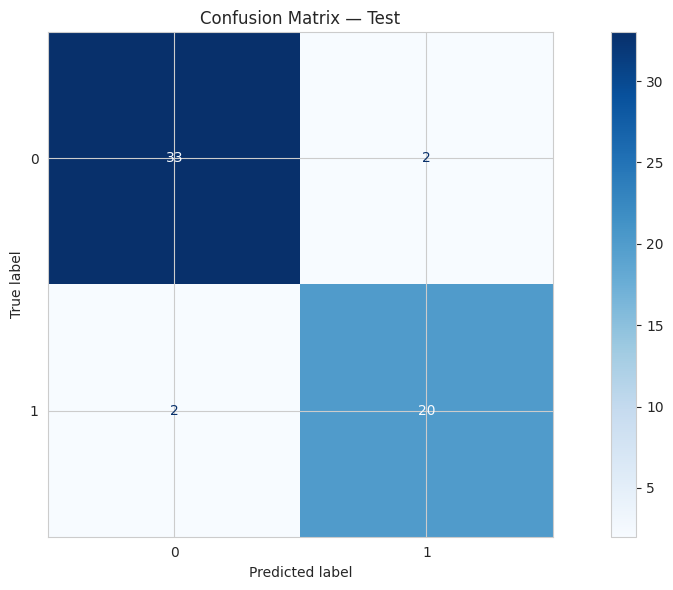

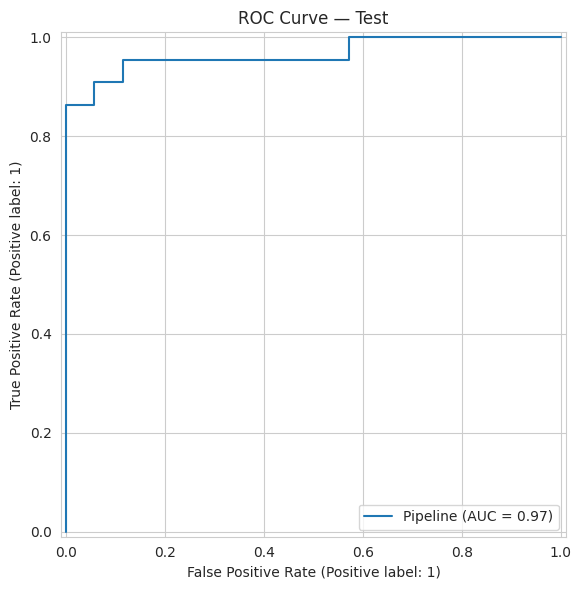

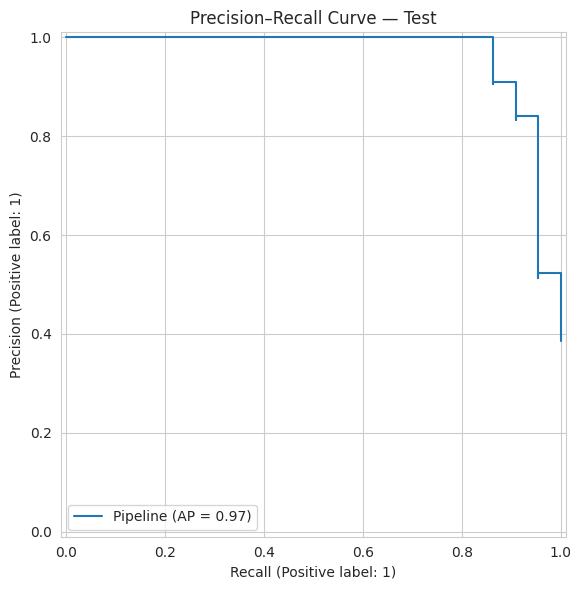

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix — Test")
plt.tight_layout(); plt.show()

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve — Test")
plt.tight_layout(); plt.show()

PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Precision–Recall Curve — Test")
plt.tight_layout(); plt.show()


,feature,importance_mean,importance_std
27,compactnessWorst,1.666667e-02,0.018793
21,smoothnessStdErr,1.403509e-02,0.010526
23,symmetryStdErr,1.052632e-02,0.019536
28,symmetryWorst,1.052632e-02,0.011637
6,perimeterStdErr,9.649123e-03,0.008728
17,compactnessMean,9.649123e-03,0.008728
7,areaStdErr,9.649123e-03,0.017077
24,fractalDimensionStdErr,7.894737e-03,0.010342
2,areaMean,7.017544e-03,0.012892
11,perimeterWorst,6.140351e-03,0.010040


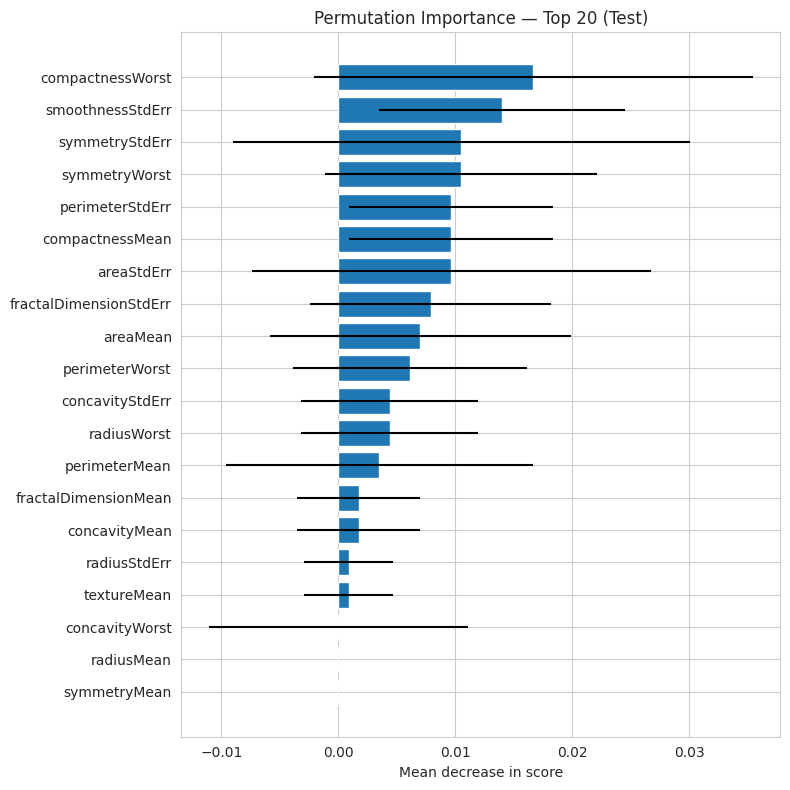

In [31]:
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1
)

# Get transformed feature names produced by the ColumnTransformer
try:
    feature_names = best_model.named_steps["prep"].get_feature_names_out()
except AttributeError:
    feature_names = [f"f{i}" for i in range(best_model.named_steps["prep"].transform(X_test).shape[1])]

imp_df = (pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
})
.sort_values("importance_mean", ascending=False)
.head(20))

display(imp_df)

plt.figure(figsize=(8, 8))
plt.barh(imp_df["feature"], imp_df["importance_mean"], xerr=imp_df["importance_std"])
plt.gca().invert_yaxis()
plt.title("Permutation Importance — Top 20 (Test)")
plt.xlabel("Mean decrease in score")
plt.tight_layout(); plt.show()


In [32]:
from sklearn.metrics import f1_score, precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, y_prob)
f1 = 2 * (prec * rec) / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1)
best_thr = thr[best_idx]

print(f"Best F1 threshold: {best_thr:.3f} | F1: {f1[best_idx]:.4f} | P: {prec[best_idx]:.4f} | R: {rec[best_idx]:.4f}")

y_pred_thr = (y_prob >= best_thr).astype(int)
print("\nRe-evaluated with tuned threshold:")
print("Precision:", precision_score(y_test, y_pred_thr))
print("Recall   :", recall_score(y_test, y_pred_thr))
print("F1       :", f1_score(y_test, y_pred_thr))


Best F1 threshold: 0.665 | F1: 0.9268 | P: 1.0000 | R: 0.8636

Re-evaluated with tuned threshold:
Precision: 1.0
Recall   : 0.8636363636363636
F1       : 0.926829268292683


In [33]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_distributions = {
    "rf__n_estimators": randint(300, 1500),
    "rf__max_depth": [None] + list(range(4, 25)),
    "rf__min_samples_leaf": randint(1, 6),
    "rf__max_features": uniform(0.3, 0.7),  # fraction of features
    "rf__bootstrap": [True, False],
    "rf__class_weight": ["balanced", "balanced_subsample"]
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=60,                # ↑ iterations for higher fidelity
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1
)

search.fit(X_train, y_train)
print("Best ROC-AUC:", search.best_score_)
print("Best params:", search.best_params_)
best_model = search.best_estimator_


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best ROC-AUC: 0.9905534627644161
Best params: {'rf__bootstrap': True, 'rf__class_weight': 'balanced_subsample', 'rf__max_depth': 5, 'rf__max_features': np.float64(0.8379878100144162), 'rf__min_samples_leaf': 1, 'rf__n_estimators': 1495}


In [34]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.92)]
print("Dropping highly correlated features:", to_drop)

X_reduced = X.drop(columns=to_drop)


Dropping highly correlated features: ['perimeterMean', 'areaMean', 'concavePointsMean', 'perimeterStdErr', 'areaStdErr', 'radiusWorst', 'perimeterWorst', 'areaWorst', 'concavePointsWorst']


In [35]:
from sklearn.metrics import precision_recall_curve, f1_score

y_prob = best_model.predict_proba(X_test)[:,1]
prec, rec, thr = precision_recall_curve(y_test, y_prob)
f1 = 2 * prec * rec / (prec + rec + 1e-9)

best_thr = thr[np.nanargmax(f1)]
print(f"Optimal threshold for max F1: {best_thr:.3f}")


Optimal threshold for max F1: 0.539


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

RANDOM_STATE = 42

# Reuse `pipe` from earlier: Pipeline([("prep", preprocess), ("rf", RandomForestClassifier(...))])
# If you don't have it, rebuild quickly:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# --- (Re)define preprocess if needed ---
heavy_mask = X.columns.str.contains(r"(radius|perimeter|area|concavity|concavePoints)", case=False, regex=True)
log_features = X.columns[heavy_mask].tolist()
linear_features = [c for c in X.select_dtypes(np.number).columns if c not in log_features]

preprocess = ColumnTransformer(
    transformers=[
        ("log_then_scale", Pipeline([
            ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("scale", RobustScaler())
        ]), log_features),
        ("scale_only", RobustScaler(), linear_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

rf_base = RandomForestClassifier(
    n_estimators=600,
    class_weight="balanced_subsample",  # let each bootstrap sample reflect class balance
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    oob_score=False  # we'll enable OOB in a separate experiment
)

pipe = Pipeline([("prep", preprocess), ("rf", rf_base)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_distributions = {
    "rf__n_estimators": randint(500, 1500),          # bigger forest → stabler
    "rf__max_depth": [None] + list(range(6, 28)),    # allow deeper trees
    "rf__min_samples_split": randint(2, 12),         # split criterion
    "rf__min_samples_leaf": randint(1, 8),           # smoother boundaries
    "rf__max_features": uniform(0.3, 0.7),           # fraction of features per split
    "rf__bootstrap": [True],                          # RF default; keep consistent
    "rf__min_impurity_decrease": [0.0, 1e-4, 1e-3],  # light regularization
    "rf__ccp_alpha": [0.0, 1e-4, 5e-4, 1e-3]         # post-pruning
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=80,                 # increase for more fidelity if time allows (e.g., 150)
    scoring="roc_auc",         # or "f1" if that’s your primary goal
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=True,
    verbose=1
)

search.fit(X_train, y_train)
print("Best CV ROC-AUC:", search.best_score_)
print("Best params:\n", search.best_params_)
rf_best = search.best_estimator_

# Evaluate on test
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
y_prob = rf_best.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)
print("\nTest metrics (RandomizedSearch best):")
print(" Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("   Recall:", recall_score(y_test, y_pred))
print("       F1:", f1_score(y_test, y_pred))
print("  ROC-AUC:", roc_auc_score(y_test, y_prob))
# print("   PR-AUC:", average_precision_score(y_test, y_prob))


Fitting 5 folds for each of 80 candidates, totalling 400 fits


/home/admdekapfer/.local/share/uv/python/cpython-3.13.9-linux-aarch64-gnu/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/admdekapfer/.local/share/uv/python/cpython-3.13.9-linux-aarch64-gnu/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/admdekapfer/.local/share/uv/python/cpython-3.13.9-linux-aarch64-gnu/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/e

Best CV ROC-AUC: 0.9941176470588236
Best params:
 {'rf__bootstrap': True, 'rf__ccp_alpha': 0.0, 'rf__max_depth': 23, 'rf__max_features': np.float64(0.8744476330207687), 'rf__min_impurity_decrease': 0.001, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 667}

Test metrics (RandomizedSearch best):
 Accuracy: 0.9122807017543859
Precision: 0.8695652173913043
   Recall: 0.9090909090909091
       F1: 0.8888888888888888
  ROC-AUC: 0.9662337662337662
   PR-AUC: 0.9643992371265098


In [38]:
rf_oob = RandomForestClassifier(
    n_estimators=800,
    bootstrap=True,
    oob_score=True,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

pipe_oob = Pipeline([("prep", preprocess), ("rf", rf_oob)])

param_grid_oob = {
    "rf__max_depth": [None, 10, 16, 22],
    "rf__min_samples_leaf": [1, 2, 3, 5],
    "rf__max_features": ["sqrt", "log2", 0.4, 0.6],
}

from sklearn.model_selection import GridSearchCV
grid_oob = GridSearchCV(
    pipe_oob, param_grid_oob,
    scoring="roc_auc", cv=cv, n_jobs=-1, refit=True
)
grid_oob.fit(X_train, y_train)

best_oob = grid_oob.best_estimator_
print("Best (OOB-enabled) params:", grid_oob.best_params_)
print("Best CV ROC-AUC:", grid_oob.best_score_)
print("OOB score of final RF:",
      best_oob.named_steps["rf"].oob_score_ if hasattr(best_oob.named_steps["rf"], "oob_score_") else "N/A")


Best (OOB-enabled) params: {'rf__max_depth': None, 'rf__max_features': 0.6, 'rf__min_samples_leaf': 2}
Best CV ROC-AUC: 0.9924659518980006
OOB score of final RF: 0.9473684210526315


In [39]:
candidates = [
    {"rf__max_features": "sqrt", "rf__min_samples_leaf": 1},
    {"rf__max_features": 0.4,    "rf__min_samples_leaf": 1},
    {"rf__max_features": 0.4,    "rf__min_samples_leaf": 2},
    {"rf__max_features": 0.3,    "rf__min_samples_leaf": 3},
    {"rf__max_features": 0.5,    "rf__min_samples_leaf": 3},
]

from sklearn.base import clone
best_auc, best_model = -np.inf, None
for i, params in enumerate(candidates, 1):
    model = clone(rf_best)
    model.set_params(**params)
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, p)
    print(f"Variant {i} {params} | Test ROC-AUC: {auc:.4f}")
    if auc > best_auc:
        best_auc, best_model = auc, model

print("Best variant AUC:", best_auc)
rf_best = best_model


Variant 1 {'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1} | Test ROC-AUC: 0.9701
Variant 2 {'rf__max_features': 0.4, 'rf__min_samples_leaf': 1} | Test ROC-AUC: 0.9662
Variant 3 {'rf__max_features': 0.4, 'rf__min_samples_leaf': 2} | Test ROC-AUC: 0.9675
Variant 4 {'rf__max_features': 0.3, 'rf__min_samples_leaf': 3} | Test ROC-AUC: 0.9688
Variant 5 {'rf__max_features': 0.5, 'rf__min_samples_leaf': 3} | Test ROC-AUC: 0.9688
Best variant AUC: 0.9701298701298702


In [40]:
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score

y_prob = rf_best.predict_proba(X_test)[:,1]
prec, rec, thr = precision_recall_curve(y_test, y_prob)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1)
best_thr = thr[best_idx]
print(f"Best F1 threshold: {best_thr:.3f}  | F1: {f1[best_idx]:.4f}  | P: {prec[best_idx]:.4f}  | R: {rec[best_idx]:.4f}")

# Re-evaluate at tuned threshold
y_pred_tuned = (y_prob >= best_thr).astype(int)
print("\nTuned-threshold metrics:")
print(" Precision:", precision_score(y_test, y_pred_tuned))
print("    Recall:", recall_score(y_test, y_pred_tuned))
print("        F1:", f1_score(y_test, y_pred_tuned))


Best F1 threshold: 0.542  | F1: 0.9302  | P: 0.9524  | R: 0.9091

Tuned-threshold metrics:
 Precision: 0.9523809523809523
    Recall: 0.9090909090909091
        F1: 0.9302325581395349


In [42]:
import numpy as np
import pandas as pd
from time import perf_counter

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay

RANDOM_STATE = 42

def evaluate_holdout(model, X_train, y_train, X_test, y_test, average='binary', pos_label=1):
    t0 = perf_counter()
    model.fit(X_train, y_train)
    fit_time = perf_counter() - t0
    
    y_pred = model.predict(X_test)
    # Für ROC-AUC: falls das Modell decision_function hat, nimm das; sonst predict_proba.
    if hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    elif hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = None
    
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average=average, pos_label=pos_label),
        "recall": recall_score(y_test, y_pred, average=average, pos_label=pos_label),
        "f1": f1_score(y_test, y_pred, average=average, pos_label=pos_label),
        "fit_time_s": fit_time,
    }
    if y_score is not None:
        # Binary ROC-AUC (bei Multiclass ggf. average='ovr' + needs_proba=True in CV)
        metrics["roc_auc"] = roc_auc_score(y_test, y_score)
    return metrics, y_pred, y_score

def cv_summary(estimator, X, y, scoring, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    cv_res = cross_validate(estimator, X, y, scoring=scoring, cv=cv, n_jobs=-1, return_train_score=False)
    # Mittelwerte + Std
    mean = {f"cv_{k}_mean": np.mean(v) for k, v in cv_res.items() if k.startswith("test_") or k.endswith("score")}
    std  = {f"cv_{k}_std":  np.std(v)  for k, v in cv_res.items() if k.startswith("test_") or k.endswith("score")}
    times = {k: np.mean(v) for k, v in cv_res.items() if "time" in k}
    return {**mean, **std, **times}


In [43]:
from sklearn.svm import SVC

# Optional: Class Imbalance mit class_weight='balanced' (bei stark unausgeglichenen Targets aktivieren)
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(probability=True, random_state=RANDOM_STATE, class_weight=None))  # setze class_weight='balanced' bei Bedarf
])

svm_param_grid = {
    "clf__kernel": ["rbf"],          # "linear" als Alternative möglich
    "clf__C": [0.1, 1, 10, 100],
    "clf__gamma": ["scale", 0.1, 0.01]
    # Bei linearem Kernel könntest du zusätzlich "clf__kernel": ["linear"] und dann nur C variieren.
}

svm_scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring="roc_auc",                 # Primär-Kriterium für Auswahl (kannst du anpassen)
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    refit=True,                        # best_estimator_ wird anhand scoring refit-t
    verbose=0
)


/home/admdekapfer/.local/share/uv/python/cpython-3.13.9-linux-aarch64-gnu/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/admdekapfer/.local/share/uv/python/cpython-3.13.9-linux-aarch64-gnu/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/admdekapfer/.local/share/uv/python/cpython-3.13.9-linux-aarch64-gnu/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/e

SVM best params: {'clf__C': 10, 'clf__gamma': 0.01, 'clf__kernel': 'rbf'}
SVM Holdout: {'accuracy': 0.9649122807017544, 'precision': 1.0, 'recall': 0.9090909090909091, 'f1': 0.9523809523809523, 'fit_time_s': 0.002704211001400836, 'roc_auc': 0.9792207792207792}
SVM CV: {'cv_test_accuracy_mean': np.float64(0.9692753623188406), 'cv_test_precision_mean': np.float64(0.9777089783281735), 'cv_test_recall_mean': np.float64(0.9411764705882353), 'cv_test_f1_mean': np.float64(0.9582086765910296), 'cv_test_roc_auc_mean': np.float64(0.9979281367719501), 'cv_test_accuracy_std': np.float64(0.010813489276264864), 'cv_test_precision_std': np.float64(0.0273709425452636), 'cv_test_recall_std': np.float64(0.037203266590216236), 'cv_test_f1_std': np.float64(0.015497687131332408), 'cv_test_roc_auc_std': np.float64(0.0026350055644877787), 'fit_time': np.float64(0.002581501007080078), 'score_time': np.float64(0.0035980701446533202)}
SVM Confusion Matrix:
 [[35  0]
 [ 2 20]]


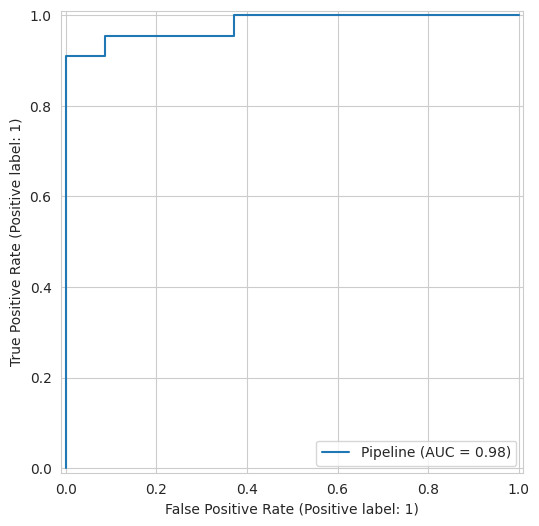

In [44]:
# X_train, X_test, y_train, y_test bereits vorhanden?
svm_grid.fit(X_train, y_train)
svm_best = svm_grid.best_estimator_

svm_holdout_metrics, svm_y_pred, svm_y_score = evaluate_holdout(svm_best, X_train, y_train, X_test, y_test)
svm_cv_metrics = cv_summary(svm_best, X_train, y_train, scoring=svm_scoring, n_splits=5)

print("SVM best params:", svm_grid.best_params_)
print("SVM Holdout:", svm_holdout_metrics)
print("SVM CV:", svm_cv_metrics)

# Optional: ROC-Kurve plotten
try:
    RocCurveDisplay.from_estimator(svm_best, X_test, y_test)
except Exception:
    pass

# Optional: Confusion Matrix
print("SVM Confusion Matrix:\n", confusion_matrix(y_test, svm_y_pred))


In [45]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline([
    ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_param_grid = {
    "clf__n_estimators": [100, 300],
    "clf__learning_rate": [0.05, 0.1, 0.2],
    "clf__max_depth": [2, 3],
    "clf__subsample": [1.0, 0.8],      # Stochastic GB kann generalisieren
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [1, 2]
}

gb_scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    refit=True,
    verbose=0
)


GB best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2, 'clf__n_estimators': 300, 'clf__subsample': 1.0}
GB Holdout: {'accuracy': 0.9473684210526315, 'precision': 1.0, 'recall': 0.8636363636363636, 'f1': 0.926829268292683, 'fit_time_s': 0.24803537200205028, 'roc_auc': 0.9636363636363636}
GB CV: {'cv_test_accuracy_mean': np.float64(0.9516908212560388), 'cv_test_precision_mean': np.float64(0.9452777777777778), 'cv_test_recall_mean': np.float64(0.9294117647058823), 'cv_test_f1_mean': np.float64(0.9355884028252449), 'cv_test_roc_auc_mean': np.float64(0.9966676325702695), 'cv_test_accuracy_std': np.float64(0.016535576317060114), 'cv_test_precision_std': np.float64(0.04749593874775889), 'cv_test_recall_std': np.float64(0.04401949866792873), 'cv_test_f1_std': np.float64(0.022188912007813425), 'cv_test_roc_auc_std': np.float64(0.0048953305823731365), 'fit_time': np.float64(0.2112443447113037), 'score_time': np.float64(0.00442557

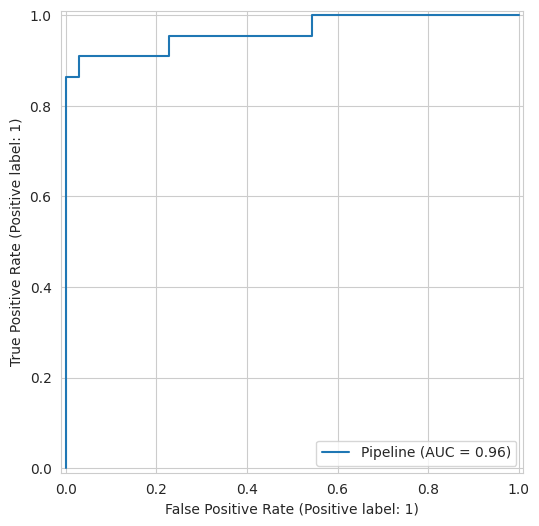

In [46]:
gb_grid.fit(X_train, y_train)
gb_best = gb_grid.best_estimator_

gb_holdout_metrics, gb_y_pred, gb_y_score = evaluate_holdout(gb_best, X_train, y_train, X_test, y_test)
gb_cv_metrics = cv_summary(gb_best, X_train, y_train, scoring=gb_scoring, n_splits=5)

print("GB best params:", gb_grid.best_params_)
print("GB Holdout:", gb_holdout_metrics)
print("GB CV:", gb_cv_metrics)

try:
    RocCurveDisplay.from_estimator(gb_best, X_test, y_test)
except Exception:
    pass

print("GB Confusion Matrix:\n", confusion_matrix(y_test, gb_y_pred))


In [47]:
def flat_metrics(prefix, holdout_dict, cv_dict):
    row = {f"{prefix}_holdout_{k}": v for k, v in holdout_dict.items()}
    row.update({f"{prefix}_{k}": v for k, v in cv_dict.items()})
    return row

rows = []
rows.append(flat_metrics("SVM", svm_holdout_metrics, svm_cv_metrics))
rows.append(flat_metrics("GB",  gb_holdout_metrics,  gb_cv_metrics))
results_df = pd.DataFrame(rows).T  # transponiert -> besserer Überblick
results_df


,0,1
SVM_holdout_accuracy,0.964912,NaN
SVM_holdout_precision,1.000000,NaN
SVM_holdout_recall,0.909091,NaN
SVM_holdout_f1,0.952381,NaN
SVM_holdout_fit_time_s,0.002704,NaN
SVM_holdout_roc_auc,0.979221,NaN
SVM_cv_test_accuracy_mean,0.969275,NaN
SVM_cv_test_precision_mean,0.977709,NaN
SVM_cv_test_recall_mean,0.941176,NaN
SVM_cv_test_f1_mean,0.958209,NaN


In [52]:
# Testdatei einlesen
test_df = pd.read_csv("../data/breast-cancer-diagnostic.shuf.tes.csv")

# Optional prüfen, wie sie aussieht
print(test_df.head())
print(test_df.columns)


         ID  radiusMean   textureMean   perimeterMean   areaMean  \
0    884437      10.480         19.86           66.72      337.7   
1    901011      11.140         14.07           71.24      384.6   
2    865432      14.500         10.89           94.28      640.7   
3    894329       9.042         18.90           60.07      244.5   
4  84348301      11.420         20.38           77.58      386.1   

    smoothnessMean   compactnessMean   concavityMean   concavePointsMean  \
0          0.10700           0.05971         0.04831             0.03070   
1          0.07274           0.06064         0.04505             0.01471   
2          0.11010           0.10990         0.08842             0.05778   
3          0.09968           0.19720         0.19750             0.04908   
4          0.14250           0.28390         0.24140             0.10520   

    symmetryMean  ...   radiusWorst   textureWorst   perimeterWorst  \
0         0.1737  ...         11.48          29.46            7

In [ ]:
# Beim Einlesen/vor dem Fit unbedingt:
train_df.columns = train_df.columns.str.strip()
valid_df.columns = valid_df.columns.str.strip()   # falls du ein eigenes val-Set hast
# Falls du X_train, X_test schon hast, dann:
X_train.columns = X_train.columns.str.strip()
X_test.columns  = X_test.columns.str.strip()

# Für das Kaggle-Testset:
test_df = test_df.copy()
test_df.columns = test_df.columns.str.strip()


In [53]:
ids = test_df["ID"]
X_kaggle_test = test_df.drop(columns=["ID"])

In [56]:
kaggle_proba = best_model.predict_proba(X_kaggle_test)[:, 1]
kaggle_pred  = (kaggle_proba >= 0.5).astype(int)


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
-  areaMean
-  areaStdErr
-  areaWorst
-  compactnessMean
-  compactnessStdErr
- ...
Feature names seen at fit time, yet now missing:
- areaMean
- areaStdErr
- areaWorst
- compactnessMean
- compactnessStdErr
- ...


In [54]:
# Mit dem aktuell besten Modell (z.B. gb_best oder svm_best):
best_model = gb_best  # oder svm_best

# IDs stammen aus deiner Testdatei:
# test_df = pd.read_csv("...tes.csv"); ids = test_df["id"]; X_kaggle_test = test_df.drop(columns=["id"])
kaggle_proba = best_model.predict_proba(X_kaggle_test)[:, 1]
kaggle_pred  = (kaggle_proba >= 0.5).astype(int)  # oder Threshold tuning

sub = pd.DataFrame({"id": ids, "predicted": kaggle_pred})
sub.to_csv("submission.csv", index=False)
print("CSV geschrieben: submission.csv")


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
-  areaMean
-  areaStdErr
-  areaWorst
-  compactnessMean
-  compactnessStdErr
- ...
Feature names seen at fit time, yet now missing:
- areaMean
- areaStdErr
- areaWorst
- compactnessMean
- compactnessStdErr
- ...
